In [ ]:
Вариант №12

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression

PATH_TO_FILE = "Sleep_health_and_lifestyle_dataset.csv"

df = pd.read_csv(PATH_TO_FILE)


Бинаризируем столбец "Quality of Sleep", которую будем использовать для предсказания

In [ ]:
df['Quality of Sleep_level'] = df['Quality of Sleep'].apply(lambda x: 'high' if x > df['Quality of Sleep'].median() else 'low')

Выведем качество сна при разном уровне стресса

In [ ]:
sns.countplot(data=df, x='Quality of Sleep_level', hue='Stress Level')
plt.title('Качество сна при разном уровне стресса')
plt.xlabel('Уровень стресса')
plt.ylabel('Количество')
plt.show()

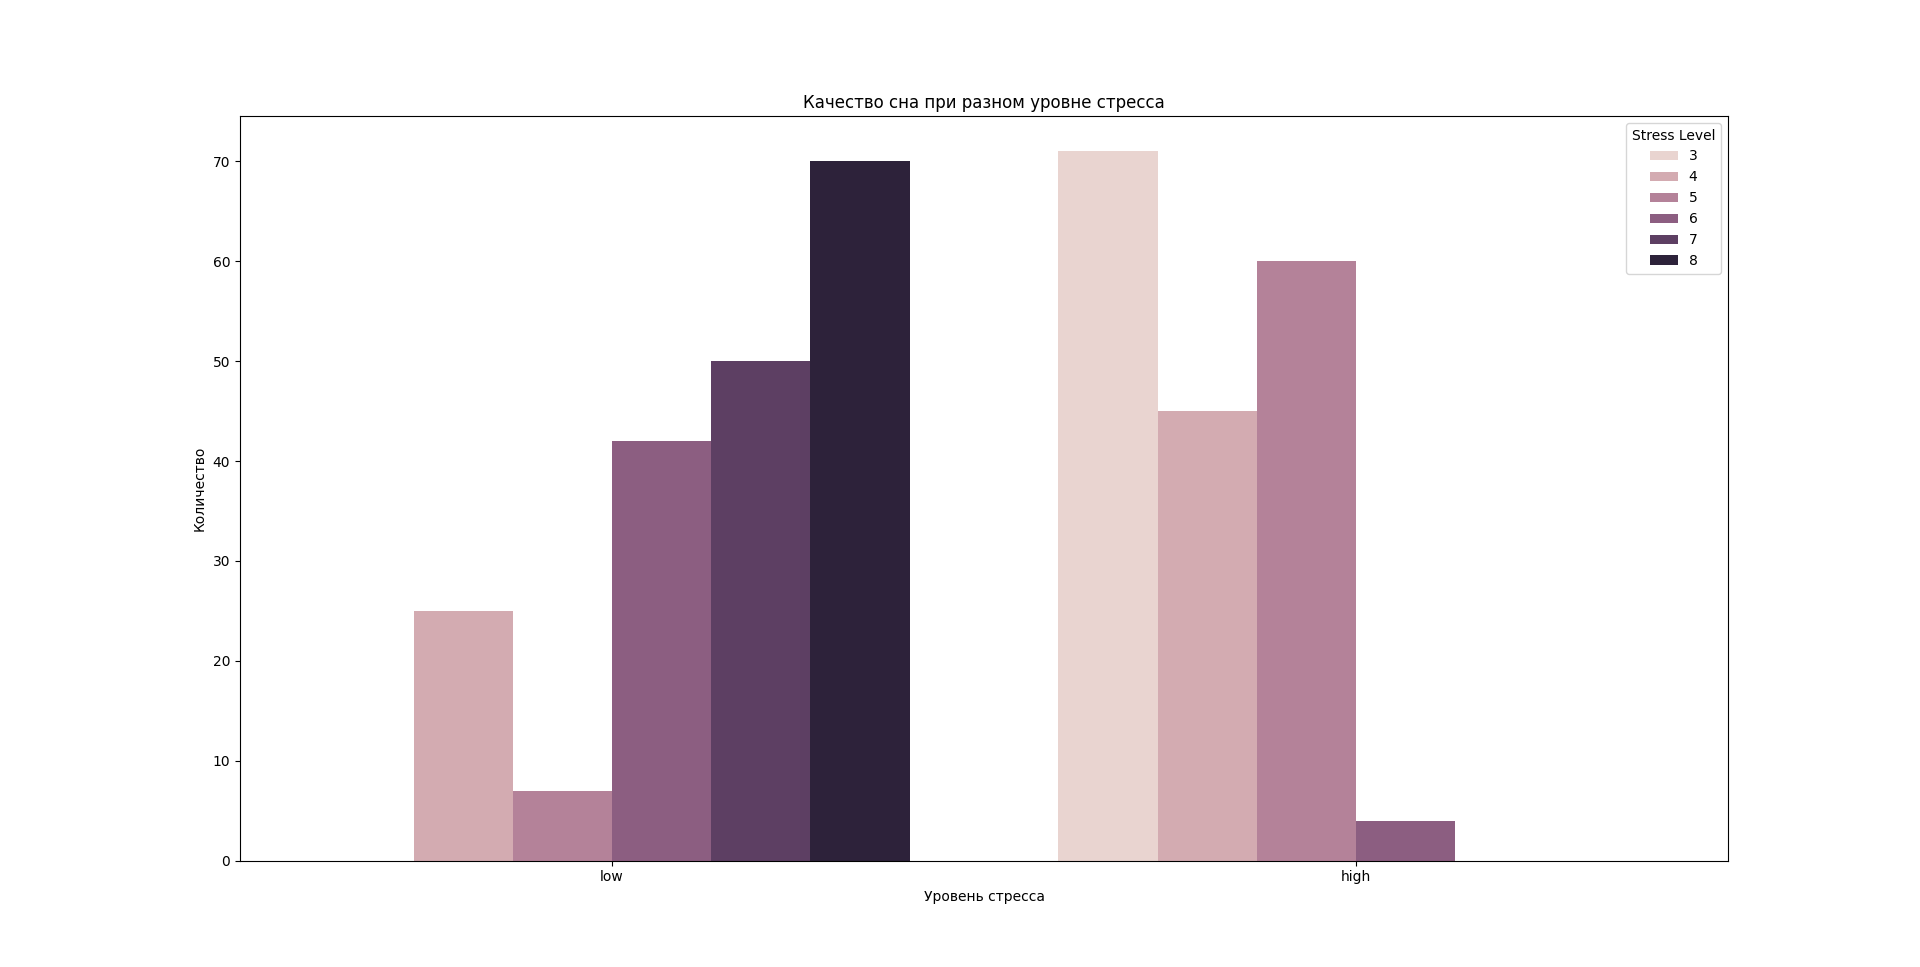

Видно, что в low качестве сна больше людей с высоким уровнем стресса, а в high качестве сна больше людей с низким уровнем стресса

Выведем гендер при разном уровне стресса

In [ ]:
sns.countplot(data=df, x='Gender', hue='Stress Level')
plt.title('Качество сна при разном уровне стресса')
plt.xlabel('Уровень стресса')
plt.ylabel('Количество')
plt.show()

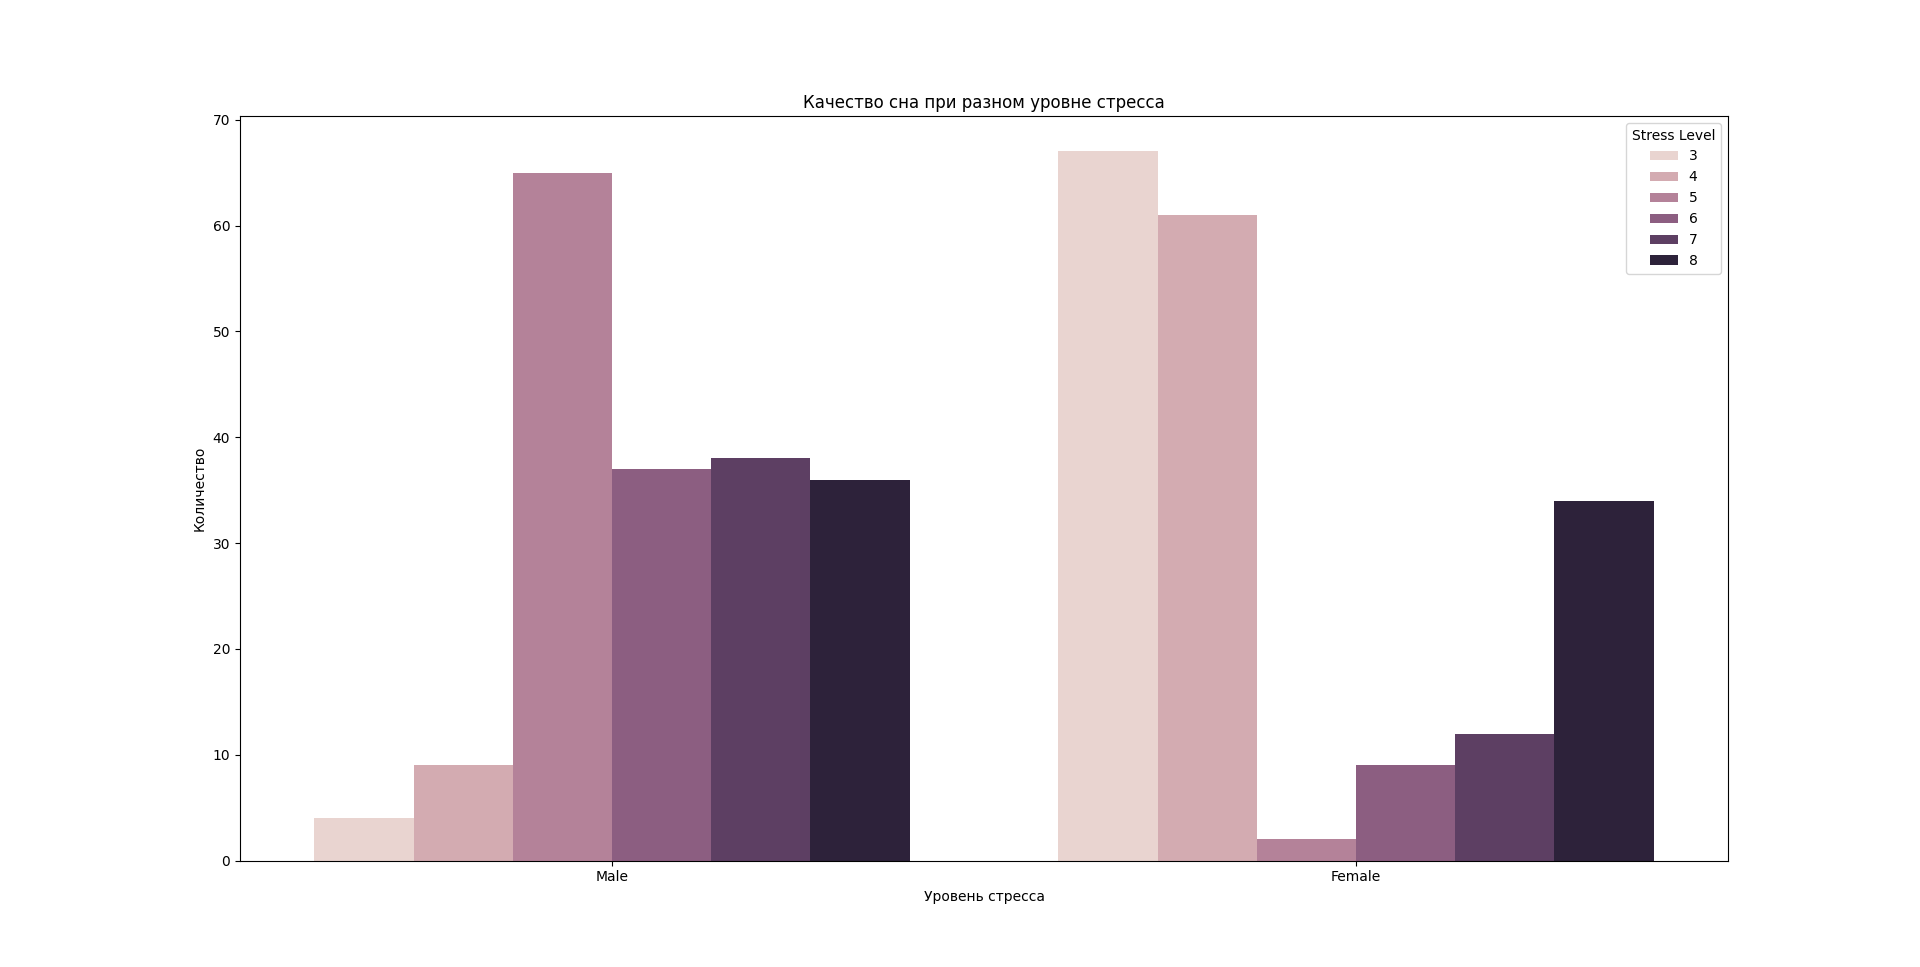

Видно, что у женщин преобладает низкий уровень стресса, а у мужчин высокий

Проверим наличие зависимости между Quality of Sleep_level и Stress Level с помощью хи-квадрат

In [ ]:
table = pd.crosstab(df['Quality of Sleep_level'], df['Stress Level'])

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)
print(f"χ² = {chi2:.2f}")
print(f"p-value = {p}")

image.png

Видно, что зависимость есть и уровень стресса влияет на качество сна

Отберём лучшие признаки

In [ ]:
from sklearn.preprocessing import StandardScaler

best_features = ['Sleep Duration', 'Heart Rate', 'Stress Level']

y = df['Quality of Sleep_level']
X = df[best_features]

X_scaled = StandardScaler().fit_transform(X)
pd.DataFrame(X_scaled, columns=X.columns).head(n=3)

Разделим выборку на тестовую и обучающую

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Создадим модель логистической регрессии и обучим её

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

Выведем метрики качества

In [ ]:
def evaluate_classification(y_true, y_pred, y_proba=None):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # ROC-AUC (если переданы вероятности)
    roc_auc = None
    if y_proba is not None:
        # Если многоклассовая классификация — One-vs-Rest
        classes = np.unique(y_true)
        y_true_onehot = np.eye(len(classes))[np.searchsorted(classes, y_true)]
        roc_auc = roc_auc_score(y_true_onehot, y_proba, multi_class='ovr')

    cm = confusion_matrix(y_true, y_pred)

    print("=== Метрики классификации ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC:   {roc_auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm
    }

In [ ]:
metrics = evaluate_classification(y_train, y_train_pred, y_train_proba)
print(metrics)

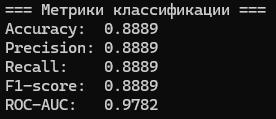

In [ ]:
metrics = evaluate_classification(y_test, y_pred, y_proba)
print(metrics)

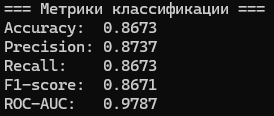

Коэффициенты модели

image.png

Модель показывает хорошие результаты в предсказании уровня качества сна, так как все метрики очень высокие и приближаются к единице.